# Évaluation de modèles
## Objectifs du TP

L'objectif principal de ce TP est de mettre en oeuvre différentes métriques d'évaluation de modèles d'apprentissage automatique.

On s'intéressera en particulier à la construction d'une matrice de confusion, au calcul de rappel et de précision ainsi qu'au calcul du F1-score.

Nous utiliserons des données synthétiques dans des modèles issus de la bibliothèque Scikit-learn (NB: si un de vos modèles est entièrement fonctionnel --arbre de décision ou réseau de neurones-- vous êtes invités à l'utiliser en priorité).

---

## Lecture et interprétation d'une matrice de confusion

Les cellules ci-dessous permettent d'afficher une matrice de confusion calculée pour un modèle permettant de prédire trois classes: `Truc`, `Machin` et `Bidule`.

La classe `ConfusionMatrixDisplay` permet simplement de faire un "joli" affichage de la matrice: vous pourrez vous en servir lors de ce TP, seule la matrice même est à calculer *from scratch*.

1. Combien d'instances comporte le jeu de données ayant permis de calculer cette matrice?
2. Que représentent les valeurs sur la diagonale de la matrice ?
3. Indiquez et expliquez quelle est la classe la plus difficile à prédire par le modèle.
5. Calculez l'exactitude du modèle.
6. Pour chacune des trois classes:
    * Décrire à quoi correspondent les vrais / faux positifs et vrais / faux négatifs *(par exemple, pour la classe `Truc`, un vrai positif est une instance prédite comme `Truc` qui est effectivement un `Truc`)*
    * Décompter les vrais positifs (TP), faux positifs (FP), faux négatifs (FN) et vrais négatifs (TN)
    * Calculer son rappel et sa précision
    * Calculer son F1-Score
7. Compléter la fonction `compute_metrics` qui permet, à partir d'une matrice de confusion passée en paramètre, de calculer et renvoyer ces différentes métriques. Pour vérifier vos calculs, n'hésitez pas à les comparer aux résultats calculés par scikit: `sklearn.metrics.precision_score`, `sklearn.metrics.recall_score` et `sklearn.metrics.f1_score`. Attention à bien spécifier qu'il s'agit d'un problème de classification *multiclasse*).

Réponses 
1) Pour trouver le nombre total d'instances, nous additionnons toutes les valeurs de la matrice de confusion :

60 + 0 + 0 + 0 + 14 + 22 + 0 + 46 + 38 = 180

2) Les valeurs sur la diagonale de la matrice représentent le nombre de prédictions correctes pour chaque classe :

5) L'exactitude (Accuracy) du modèle se calcule comme suit :

Accuracy = (Nombre de prédictions correctes) / (Nombre total d'instances)

Nombre de prédictions correctes = 60 (Truc) + 14 (Machin) + 38 (Bidule) = 112
Nombre total d'instances = 60 (Truc) + 0 + 0 + 0 + 14 + 22 + 0 + 46 + 38 = 180
Accuracy = 112 / 180 ≈ 0.6222

L'exactitude du modèle est d'environ 62.22%



In [3]:
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

def compute_metrics(cfm):
    metrics = {} # dict. de dicts {classe: {rappel: r, precision: p, f1_score: f}, ...}
    accuracy = 0
    cfm = np.asarray(cfm)  


    # TODO
    total_correct = 0
    total_samples = np.sum(cfm)

    for i in range(len(cfm)):
        tp = cfm[i, i]
        fp = np.sum(cfm[:, i]) - tp
        fn = np.sum(cfm[i, :]) - tp

        precision = tp / (tp + fp) if (tp + fp) != 0 else 0
        recall = tp / (tp + fn) if (tp + fn) != 0 else 0
        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

        metrics[i] = {
            'precision': precision,
            'recall': recall,
            'f1': f1
        }

        total_correct += tp

    accuracy = total_correct / total_samples if total_samples != 0 else 0


    return accuracy, metrics


def evaluate(cfm, model_name):
    print(f"=== Evaluation of: {model_name}")
    
    if cfm is None: return

    ConfusionMatrixDisplay(confusion_matrix=np.asarray(cfm), \
    display_labels=['Truc', 'Machin', 'Bidule']).plot()

    acc, metrics = compute_metrics(cfm)

    print(f"Accuracy: {acc:.2f}")
    for key, vals in metrics.items():
        print(f"Class {key}: Precision={vals['precision']:.2f}, Recall={vals['recall']:.2f}, F1={vals['f1']:.2f}")
    return

=== Evaluation of: Dummy cfm
Accuracy: 0.62
Class 0: Precision=1.00, Recall=1.00, F1=1.00
Class 1: Precision=0.23, Recall=0.39, F1=0.29
Class 2: Precision=0.63, Recall=0.45, F1=0.53


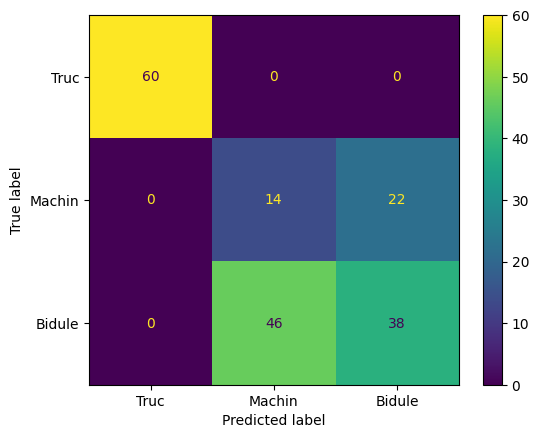

In [4]:
cfm = [[60,  0,  0],
 [ 0, 14, 22],
 [ 0, 46, 38]]

evaluate(cfm, 'Dummy cfm')

3) interprétation de la matice de confusion

 Les valeurs sur la diagonale de la matrice de confusion représentent le nombre d'instances qui ont été correctement prédites par le modèle pour chaque classe.

60 instances de la classe "Truc" ont été correctement prédites comme "Truc".
14 instances de la classe "Machin" ont été correctement prédites comme "Machin".
38 instances de la classe "Bidule" ont été correctement prédites comme "Bidule".

4) La classe la plus difficile à prédire est "Machin".

Bien que "Bidule" ait également des erreurs de classification, "Machin" a le plus petit nombre de prédictions correctes (14) par rapport au nombre d'erreurs.

22 instances de "Machin" ont été incorrectement prédites comme "Bidule", ce qui indique une confusion significative entre ces deux classes.

La précision et le rappel (indiqués en haut de l'image) sont les plus bas pour "Machin", confirmant qu'il est difficile à prédire.

6) Pour chacune des trois classes :

à quoi correspondent les vrais / faux positifs et vrais / faux négatifs
les vrais positifs (TP), faux positifs (FP), faux négatifs (FN) et vrais négatifs (TN)

Classe "Truc"

Description :

Vrai Positif (TP) : Une instance qui est réellement "Truc" et a été correctement prédite comme "Truc".
Faux Positif (FP) : Une instance qui n'est pas "Truc" mais a été incorrectement prédite comme "Truc".
Faux Négatif (FN) : Une instance qui est réellement "Truc" mais a été incorrectement prédite comme "Machin" ou "Bidule".
Vrai Négatif (TN) : Une instance qui n'est pas "Truc" et a été correctement prédite comme "Machin" ou "Bidule".

Décompte :

TP = 60
FP = 0 + 0 = 0
FN = 0 + 0 = 0
TN = 14 + 22 + 46 + 38 = 120 (Somme de toutes les cellules qui ne sont ni dans la ligne ni dans la colonne "Truc")

Classe "Machin"

Description :

Vrai Positif (TP) : Une instance qui est réellement "Machin" et a été correctement prédite comme "Machin".
Faux Positif (FP) : Une instance qui n'est pas "Machin" mais a été incorrectement prédite comme "Machin".
Faux Négatif (FN) : Une instance qui est réellement "Machin" mais a été incorrectement prédite comme "Truc" ou "Bidule".
Vrai Négatif (TN) : Une instance qui n'est pas "Machin" et a été correctement prédite comme "Truc" ou "Bidule".
Décompte :

TP = 14
FP = 0 + 46 = 46
FN = 0 + 22 = 22
TN = 60 + 0 + 0 + 38 = 98 (Somme de toutes les cellules qui ne sont ni dans la ligne ni dans la colonne "Machin")

Classe "Bidule"

Description :

Vrai Positif (TP) : Une instance qui est réellement "Bidule" et a été correctement prédite comme "Bidule".
Faux Positif (FP) : Une instance qui n'est pas "Bidule" mais a été incorrectement prédite comme "Bidule".
Faux Négatif (FN) : Une instance qui est réellement "Bidule" mais a été incorrectement prédite comme "Truc" ou "Machin".
Vrai Négatif (TN) : Une instance qui n'est pas "Bidule" et a été correctement prédite comme "Truc" ou "Machin".
Décompte :

TP = 38
FP = 0 + 22 = 22
FN = 0 + 46 = 46
TN = 60 + 0 + 14 + 0 = 74 (Somme de toutes les cellules qui ne sont ni dans la ligne ni dans la colonne "Bidule")




---

## Entrainer un modèle et générer des prédictions

### Chargement des données

Les cellules suivantes permettent de charger les données et d'explorer brièvement la distribution de leurs attributs et la distribution des classes.

* Exécuter ces cellules et commenter leurs résultats

In [ ]:
import pandas as pd

df = pd.read_csv('synthetic_dataset.csv')

# Récupération des noms des colonnes
feature_names = df.columns[:-1]
class_names   = df['label'].astype('category').cat.categories

# Séparation des attributs et de la cible
X = df[feature_names]
y = df['label']


print(feature_names)import pandas as pd

# Load the dataset
df = pd.read_csv('synthetic_dataset.csv')

# Get feature and class names
feature_names = df.columns[:-1]
class_names = df['label'].astype('category').cat.categories

# Split data into features and target
X = df[feature_names]
y = df['label']

# Print feature and class names
print("Feature Names:")
print(feature_names)
print("\nClass Names:")
print(class_names)

# Print dataset summary statistics
print("\nDataset Summary Statistics:")
print(df.describe())
print(class_names)
print(df.describe())

Index(['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4',
       'feature_5', 'feature_6', 'feature_7'],
      dtype='object')
Index([0, 1, 2, 3], dtype='int64')
         feature_0    feature_1    feature_2    feature_3    feature_4  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean      0.326368     0.716082     0.120192     0.537248    -0.380215   
std       1.446919     1.552674     2.572719     1.510778     1.538555   
min      -4.366020    -4.330591    -7.897457    -4.155356    -4.316512   
25%      -0.626678    -0.289013    -1.388639    -0.460809    -1.435611   
50%       0.354720     0.701151     0.347236     0.659706    -0.602331   
75%       1.223852     1.685593     1.820635     1.513329     0.389818   
max       4.737464     6.989706     7.892884     5.673657     5.981657   

         feature_5    feature_6    feature_7        label  
count  1000.000000  1000.000000  1000.000000  1000.000000  
mean      0.348912    -0.042531     0

Commentaires 

statistiques descriptives






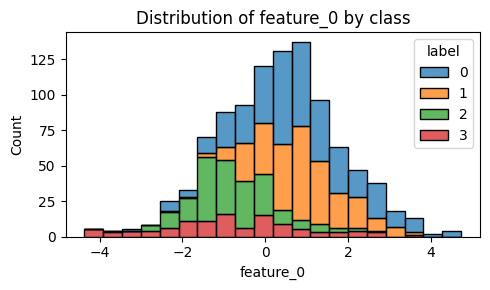

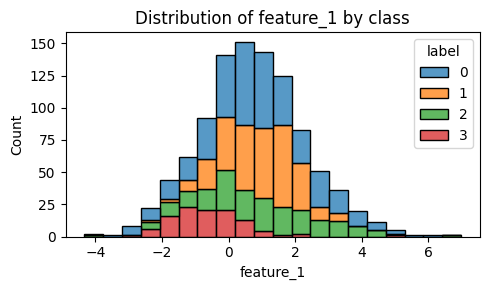

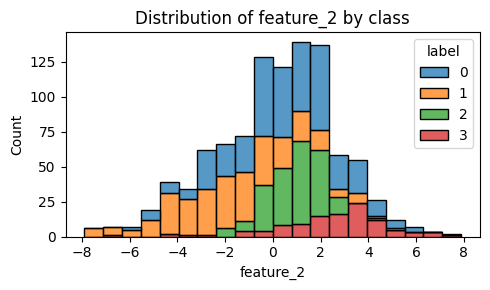

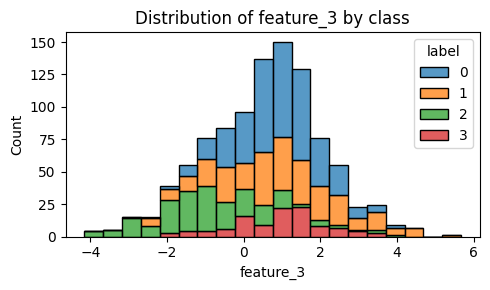

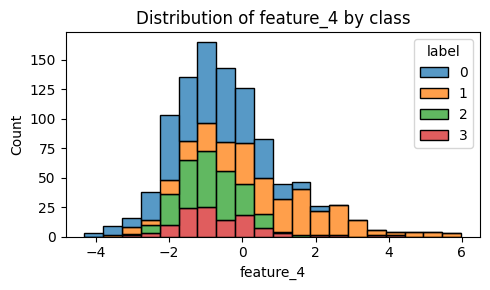

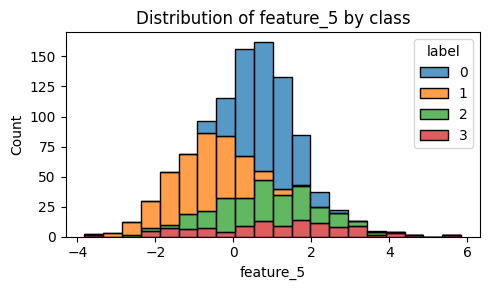

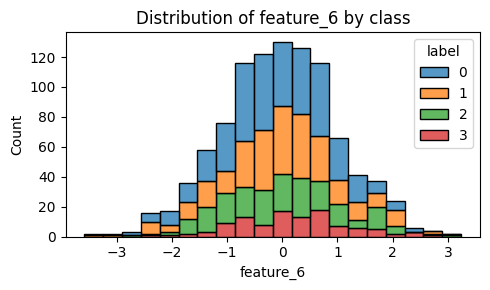

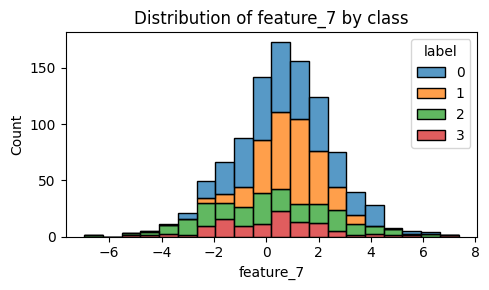

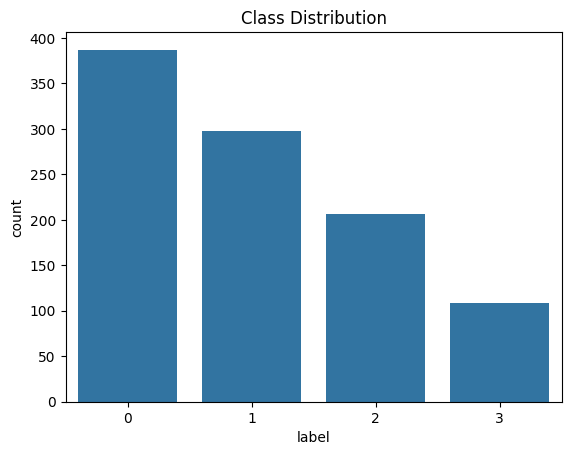

In [6]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import matplotlib.pyplot as plt
import seaborn as sns

# Visualisation des distributions des attributs
for feature in feature_names:
    plt.figure(figsize=(5, 3))
    sns.histplot(data=df, x=feature, hue="label", multiple="stack", bins=20, palette="tab10")
    plt.title(f"Distribution of {feature} by class")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# Visualisation de la distribution des classes
sns.countplot(x='label', data=df)
plt.title("Class Distribution")
plt.show()

---

### Entraînement d'un modèle

La cellule ci-dessous permet de (1) séparer les données en un jeu d'entrainement et un jeu de test, (2) normaliser les données et (3) instancier et entrainer un modèle des k plus proches voisins.

* Quelle proportion des données est-elle assignée à l'ensemble de test ?
* Le `scaler` instancié réalise-t-il une mise à l'échelle ou une standardisation ? Rappelez la différence entre ces deux manières de normaliser les données.
    * Pourquoi la normalisation peut-elle être nécessaire ?
    * L'est-elle dans le cas de l'utilisation d'un KNN ?
* Pensez-vous qu'il aurait été correct de d'abord normaliser les données, *puis* de les séparer en train / test ?
* À quoi correspond le score calculé par `clf_knn.score(X_test_scaled, y_test)` ?

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# 1. Split des données en deux ensembles
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, \
    test_size=0.2, random_state=42)
    # `stratify` : préserve la distribution des classes de X
    # dans les sous-ensembles créés

# 2. Normalisation des données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 3. Instancier et entrainer un KNN
clf_knn = KNeighborsClassifier()
clf_knn.fit(X_train_scaled, y_train)
y_pred_knn = clf_knn.predict(X_test_scaled)
clf_knn.score(X_test_scaled, y_test)

0.89

### Évaluation du modèle

* Écrivez la fonction `compute_confusion_matrix` qui, à partir de la vérité terrain et des prédictions réalisées par un modèle correspondantes, permet de calculer une matrice de confusion.

Pour l'instant, on part du principe que la classe prédite pour une instance $i$ correspond au maximum de la distribution de probabilité calculée pour cette instance.

In [8]:
def compute_confusion_matrix(y_true, y_pred, num_classes):
    matrix = None
    # TODO
    return matrix

cfm_knn = compute_confusion_matrix(y, y_pred_knn, len(y.unique()))

evaluate(cfm_knn, 'KNN')

=== Evaluation of: KNN


## Comparaison de modèles

On va maintenant s'intéresser à la comparaison de différents modèles. Il s'agira de comparer leurs performances sur un jeu de validation, puis de sélectionner le modèle le plus performant sur ce jeu et de réaliser une évaluation finale sur un jeu de test.

Vous allez ici entraîner trois modèles: un KNN, comme précédemment, mais aussi un modèle linéaire de type "ridge" ainsi qu'un modèle "dummy" servant de contrôle (i.e. il s'agit d'un modèle de base, qui classe les données au hasard ou bien assigne la classe majoritaire du jeu de données. On s'attend évidemment à ce que n'importe quel autre modèle obtiennent de meilleures performances).

Pour comparer les modèles, on propose d'utiliser un F1-Score "global", qui correspond à la moyenne des F1-score de chaque classe pour chaque modèle. Le "meilleur" modèle est celui obtenant le meilleur F1-Score.

* Modifiez votre fonction `compute_metrics` pour qu'elle renvoie un tuple `accuracy, global_f1, metrics`
* Completez la cellule ci-dessous.
* Discutez la méthode de sélection du meilleur modèle: le F1-score est-il nécessairement le meilleur critère à examiner ? Imaginez et décrivez un cas dans lequel vous auriez favorisé une autre métrique.

In [9]:
from sklearn.linear_model import RidgeClassifier
from sklearn.dummy import DummyClassifier

# Prélevement de 20% de X pour le test
# Prélevement de 15% du jeu d'entrainement pour la validation
# TODO

# Normalisation des jeux de données
# TODO

# Entraînement des modèles: KNN, Ridge, Dummy
# TODO

# Génération de prédiction sur les données de validation pour chaque modèle
# TODO

# Calcul des métriques de performances pour chacun des trois modèles
# TODO

# Évaluation finale du meilleur modèle sur les données de test
# TODO

## Examen des seuils de classification sur les performances

Pour classer une instance $i$, sélectionner la valeur maximale de la distribution de probabilité calculée par le modèle ne permet pas de rendre compte de la "certitude" du modèle quant à la classification.

On va s'intéresser, dans cette partie, à l'exploration de différents seuils de classification permettant d'optimiser les performances d'un modèle.

Dans cette partie, il faudra faire générer à votre modèle une distribution de probabilités :  `y_proba = clf.predict_proba(X_test_scaled)`. La variable `y_proba` aura donc pour dimension `(n_samples, n_classes)`.

Ici, nous n'allons pas tracer une courbe ROC stricto-sensus, mais examiner l'influence du seuil de classification sur les métriques de performance de notre modèle. Les classes vont être examinées sous un angle "une versus toutes les autres" (donc sous un angle binaire).

$\Rightarrow$ Compléter le code de la cellule ci-dessous.

1. Comment la précision et le rappel évoluent-ils lors que le seuil diminue (resp. augmente) ?
2. Comparativement aux courbes générées ici, une courbe ROC vous permettrait-elle de déterminer une valeur de seuil pour favoriser spécifiquement une des trois métriques que nous examinons ? 
3. Si le modèle assigne des probabilités basses à la classe correcte, même pour les vrais positifs, qu'est-ce que cela implique pour le F1-score ?
4. Pour chaque classe, affichez la probabilité moyenne calculée par le modèle. Quel parallèle pouvez-vous faire par rapport à la distribution des classes dans les données ?
5. Pour chaque classe, affichez la probabilité moyenne calculée par le modèle pour les vrais positifs. Cette valeur est-elle plus élevée ou plus basse que la valeur calculée précédemment ? Que pouvez vous en déduire sur la confiance de votre modèle ?

In [10]:
def look_at_threshold(y_pred_proba, y_test, class_index=0):
    # Sélection des probabilités calculées pour la classe class_index
    y_prob_class = y_pred_proba[:, class_index]

    # Transformer la vérité terrain en étiquette binaire: 1 si label == class_index, sinon 0
    y_test_binary = (y_test == class_index).astype(int)

    # Ensemble de seuils à tester
    thresholds = np.arange(0, 1.01, 0.1)
    precisions = []
    recalls = []
    f1s = []

    for thresh in thresholds:
        y_pred_binary = (y_prob_class >= thresh).astype(int)

        # Calculer la matrice de confusion binaire (class_index vs tous les autres!)
        # puis l'utiliser pour calculer la précision, le rappel et le f1-score
        cfm_binary = compute_confusion_matrix(y_test_binary, y_prob_class, 2)
        _, metrics = compute_metrics(cfm_binary)
        
        precision = 0 # TODO
        recall    = 0 # TODO
        f1        = 0 # TODO

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)

    plt.figure(figsize=(8, 4))
    plt.plot(thresholds, precisions, label='Precision')
    plt.plot(thresholds, recalls, label='Recall')
    plt.plot(thresholds, f1s, label='F1 Score')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title(f'Threshold vs Metrics (Class {class_index} vs other classes)')
    plt.xticks(thresholds)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return

for i in range(len(y.unique())):
    look_at_threshold(y_proba_knn, y_test, class_index=i)

NameError: name 'y_proba_knn' is not defined